In [ ]:
!unzip -q archive.zip
print("Dataset unzipped successfully")

Dataset unzipped successfully inside Colab server!


In [5]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
TRAIN_DIR = os.path.join(BASE_DIR, "data", "mrl_dataset", "train")
TEST_DIR = os.path.join(BASE_DIR, "data", "mrl_dataset", "test")
#This joins the notebook directory with location of the dataset, which is in the parent directory under mrl_dataset
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224) #Satandard size.
print("Loading training dataset")
train_dataset = image_dataset_from_directory(TRAIN_DIR, shuffle=True, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, label_mode='binary')
print("\nLoading testing dataset")
test_dataset = image_dataset_from_directory(TEST_DIR, shuffle=False, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, label_mode='binary' )
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))
print("\nDatasets are fully loaded and normalized.")

Loading training dataset
Found 20000 files belonging to 2 classes.

Loading testing dataset
Found 1000 files belonging to 2 classes.

Datasets are fully loaded and normalized.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
print("Configuring Model 1 ->Custom CNN")
model1 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')])
# To understand this code read the summary provided below cells.
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nStarting Model 1 Training")
history1 = model1.fit(train_dataset, validation_data=test_dataset, epochs=5)
print("\nConfiguring Model 2 ->MobileNetV2")
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False
model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
# To understand this code read the summary provided below cells.
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nStarting Model 2 Training")
history2 = model2.fit(train_dataset, validation_data=test_dataset, epochs=5)

--- Configuring Model 1 (Custom CNN) ---

Starting Model 1 Training on T4 GPU...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8333 - loss: 0.3759 - val_accuracy: 0.9290 - val_loss: 0.2068
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.9032 - loss: 0.2448 - val_accuracy: 0.9310 - val_loss: 0.1804
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.9147 - loss: 0.2073 - val_accuracy: 0.9540 - val_loss: 0.1438
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9255 - loss: 0.1846 - val_accuracy: 0.9580 - val_loss: 0.1404
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step - accuracy: 0.9276 - loss: 0.1707 - val_accuracy: 0.9660 - val_loss: 0.1220


--- Configuring Model 2 (MobileNetV2) ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Starting Model 2 Training on T4 GPU...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 57ms/step - accuracy: 0.9251 - loss: 0.1945 - val_accuracy: 0.9480 - val_loss: 0.1327
Epoch 2/5
62

In [ ]:
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
print("Configuring Model 3 ->VGG16")
vgg_base = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
vgg_base.trainable = False
model3 = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])
# To understand this code read the summary provided below cells.
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nStarting Model 3 Training")
history3 = model3.fit(train_dataset, validation_data=test_dataset, epochs=5)
print("\nConfiguring Model 4 ->ResNet50")
resnet_base = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
resnet_base.trainable = False
model4 = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
# To understand this code read the summary provided below cells.
model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nStarting Model 4 Training")
history4 = model4.fit(train_dataset, validation_data=test_dataset, epochs=5)
print("\nConfiguring Model 5 ->InceptionV3")
inception_base = InceptionV3(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
inception_base.trainable = False
model5 = models.Sequential([
    inception_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')])
# To understand this code read the summary provided below cells.
model5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nStarting Model 5 Training")
history5 = model5.fit(train_dataset, validation_data=test_dataset, epochs=5)

--- Configuring Model 3 (VGG16) ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Starting Model 3 Training on T4 GPU...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.7771 - loss: 0.4696 - val_accuracy: 0.9290 - val_loss: 0.2525
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.8758 - loss: 0.3213 - val_accuracy: 0.9200 - val_loss: 0.2444
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 172ms/step - accuracy: 0.8813 - loss: 0.2898 - val_accuracy: 0.9410 - val_loss: 0.1656
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.9024 - loss: 0.2589 - val_accuracy: 0.9520 - val_loss: 0.1866
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.9025 - loss: 0.2474 - val_accuracy: 0.9540 - val_loss: 0.1482


--- Configuring Model 4 (ResNet50) ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Starting Model 4 Training on T4 GPU...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 100ms/step - accuracy: 0.4970 - loss: 0.695

In [ ]:
model1.summary()
model2.summary()
model3.summary()
model4.summary()
model5.summary()

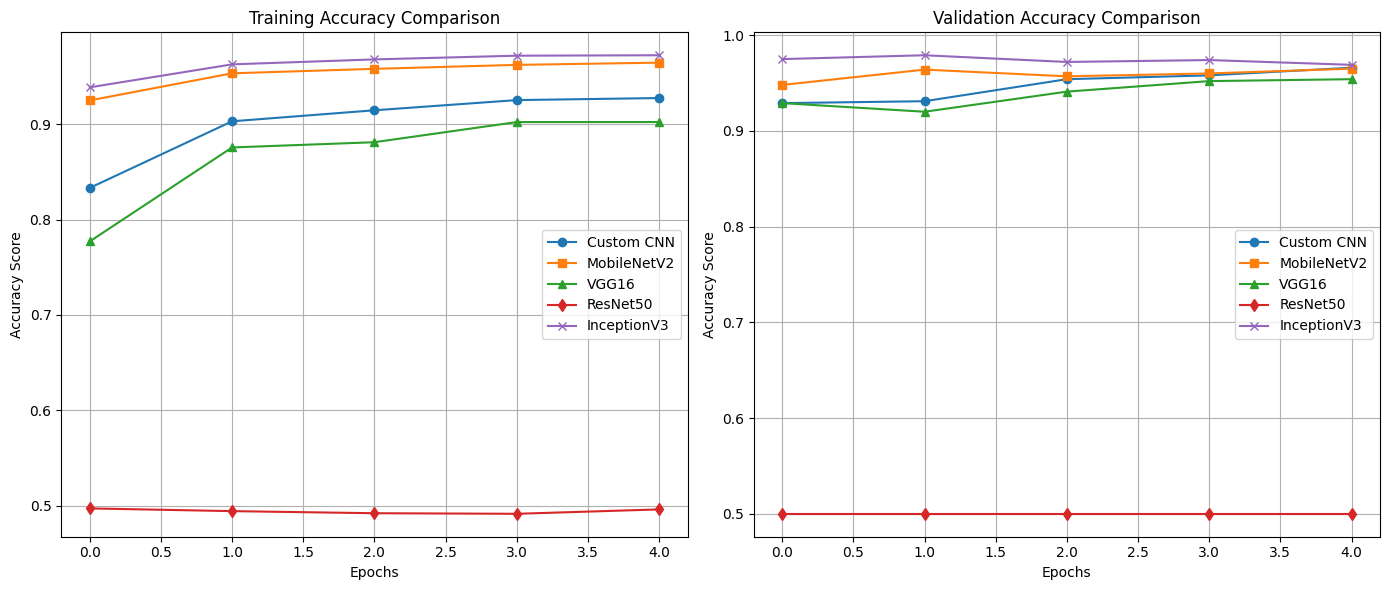

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Custom CNN', marker='o')
plt.plot(history2.history['accuracy'], label='MobileNetV2', marker='s')
plt.plot(history3.history['accuracy'], label='VGG16', marker='^')
plt.plot(history4.history['accuracy'], label='ResNet50', marker='d')
plt.plot(history5.history['accuracy'], label='InceptionV3', marker='x')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history1.history['val_accuracy'], label='Custom CNN', marker='o')
plt.plot(history2.history['val_accuracy'], label='MobileNetV2', marker='s')
plt.plot(history3.history['val_accuracy'], label='VGG16', marker='^')
plt.plot(history4.history['val_accuracy'], label='ResNet50', marker='d')
plt.plot(history5.history['val_accuracy'], label='InceptionV3', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()